# 🧠 Mental Health Intelligence Platform

## Phase 8 — Model Explainability

### Overview

Machine learning models can achieve strong predictive performance, but understanding **why** they make predictions is equally important.

This notebook explains the trained Random Forest model by identifying the features that contribute most to predicting whether an employee is likely to seek professional mental health treatment.

---

### Objectives

- Interpret the trained model
- Identify the most influential features
- Visualize feature importance
- Generate actionable business insights
- Increase transparency and trust in model predictions

In [22]:
import warnings
warnings.filterwarnings("ignore")

import joblib
import pandas as pd
import plotly.express as px

from sklearn.model_selection import train_test_split

from src.explain import (
    compute_shap_values,
    plot_shap_summary,
    plot_shap_waterfall,
    compute_permutation_importance,
    explain_prediction
)

## Load Trained Model

In [23]:
model = joblib.load("../models/best_model.pkl")

print(model)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['survey_year',
                                                   'employer_importance_physical',
                                                   'employer_importance_mental',
                                                   'have_prev_employers',
                                                   'prev_employer_importance_physical',
                                                   'prev_employer_importance_mental',
                                                   'share_with_friends_f...
           

## Load Dataset

In [24]:
df = pd.read_csv("../data/processed/ml_ready_dataset.csv")

print(df.shape)

df.head()

(3082, 62)


,survey_year,self_employed,no_employees,tech_company,primary_role_tech,benefits,know_options,formal_discussion,resources,anonymity,...,age,gender,country_live,state_live,race,country_work,state_work,age_group,workplace_support_score,sought_treatment
0,2014,NaN,6-25,Yes,NaN,Yes,Don't Know,No,Yes,Yes,...,NaN,Male,NaN,New York,Other,South Africa,NaN,NaN,3,Yes
1,2014,NaN,More than 1000,No,NaN,Don't Know,No,Don't Know,Don't Know,Don't Know,...,NaN,Other,NaN,Massachusetts,More than one of the above,Indonesia,NaN,NaN,0,No
2,2014,NaN,6-25,Yes,NaN,No,No,No,No,Don't Know,...,NaN,Other,NaN,Texas,More than one of the above,Germany,NaN,NaN,0,No
3,2014,NaN,26-100,Yes,NaN,No,Yes,No,No,No,...,NaN,Other,NaN,Other,I prefer not to answer,Canada,NaN,NaN,0,Yes
4,2014,NaN,100-500,Yes,NaN,Yes,No,Don't Know,Don't Know,Don't Know,...,NaN,Male,NaN,Ohio,White,Ethiopia,NaN,NaN,1,No


## Train/Test Split

In [25]:
TARGET = "sought_treatment"

X = df.drop(columns=TARGET)

y = df[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

## Random Forest Feature Importance

In [26]:
rf = model.named_steps["classifier"]

preprocessor = model.named_steps["preprocessor"]

feature_names = preprocessor.get_feature_names_out()

importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": rf.feature_importances_
})

importance = importance.sort_values(
    "Importance",
    ascending=False
)

importance.head(20)

,Feature,Importance
137,cat__past_disorder_Yes,0.060536
134,cat__past_disorder_No,0.054226
140,cat__family_history_Yes,0.033256
139,cat__family_history_No,0.032913
9,num__workplace_support_score,0.018579
34,cat__know_options_Yes,0.018170
6,num__share_with_friends_family,0.014658
8,num__age,0.012326
69,cat__discussed_with_employer_Yes,0.010689
67,cat__discussed_with_employer_No,0.010656


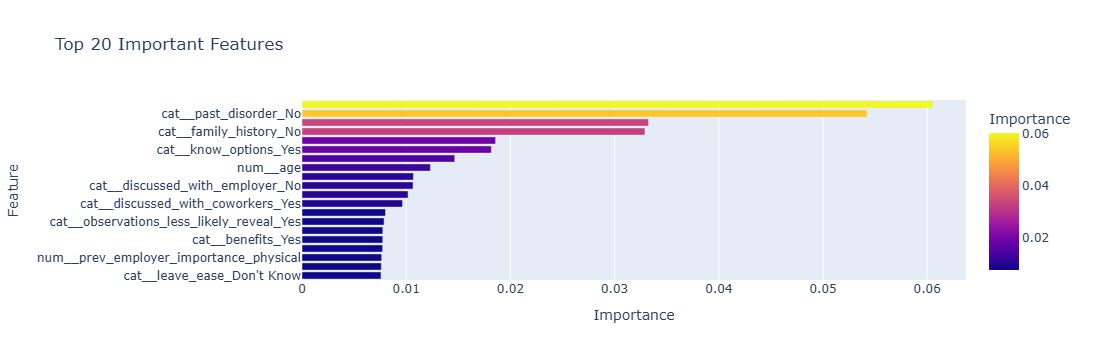

In [27]:
fig = px.bar(
    importance.head(20),
    x="Importance",
    y="Feature",
    orientation="h",
    color="Importance",
    title="Top 20 Important Features"
)

fig.update_layout(
    yaxis=dict(categoryorder="total ascending")
)

fig.show()

In [29]:
X_sample = X_test.sample(
    100,
    random_state=42
)

In [30]:
try:

    shap_result = compute_shap_values(
        model,
        X_sample
    )

    print("SHAP computed successfully!")

except Exception as e:

    print(e)

    shap_result = None

Error computing SHAP values: setting an array element with a sequence.
SHAP computed successfully!


In [31]:
if shap_result is not None:

    plot_shap_summary(
        shap_result
    )

AttributeError: 'tuple' object has no attribute 'shape'

<Figure size 1200x800 with 0 Axes>